# ⚡ Hyperparameter Tuning with Optuna

---

**Project:** Accuracy Improvement Challenge  
**Notebook:** 07 - Advanced Hyperparameter Optimization  
**Author:** Manish Kumar  
**Date:** 2025  

---

## 🎯 Objective

Use **Optuna** - a state-of-the-art hyperparameter optimization framework - to squeeze out **maximum performance** from our best models.

## 📚 What is Optuna?

**Optuna** is a next-generation hyperparameter optimization framework that uses:

- 🧠 **TPE (Tree-structured Parzen Estimator)** algorithm
- 🎯 **Bayesian Optimization** approach
- ⚡ **Automatic pruning** of bad trials
- 📊 **Visualization** dashboard

## 🔬 Why Optuna over GridSearchCV?

| Aspect | GridSearchCV | Optuna |
|--------|-------------|--------|
| Speed | Slow (tries all combos) | 10x faster |
| Intelligence | Random/Grid | Smart Bayesian |
| Pruning | ❌ No | ✅ Yes |
| Visualization | ❌ Basic | ✅ Advanced |

## 🎯 Models to Tune

1. **XGBoost** - Industry standard
2. **LightGBM** - Fast & efficient
3. **Random Forest** - Robust ensemble

In [1]:
# ============================================================
#  IMPORTS
# ============================================================

import os
import json
import pickle
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optuna
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import matplotlib as optuna_viz

# ML Libraries
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')

print("=" * 65)
print("  ✅ LIBRARIES LOADED")
print("=" * 65)
print(f"  📅 Started at    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  ⚡ Optuna version: {optuna.__version__}")
print("=" * 65)

  ✅ LIBRARIES LOADED
  📅 Started at    : 2026-07-20 09:22:55
  ⚡ Optuna version: 4.9.0


In [2]:
# ============================================================
#  LOAD ENGINEERED DATASET
# ============================================================

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_SAVED = PROJECT_ROOT / "models" / "saved_models"
MODELS_RESULTS = PROJECT_ROOT / "models" / "results"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

# Load data
df = pd.read_csv(DATA_PROCESSED / "admission_engineered.csv")
df.columns = df.columns.str.strip()
target_col = [col for col in df.columns if 'Admit' in col][0]

X = df.drop(target_col, axis=1)
y = df[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("=" * 65)
print("  📂 DATA LOADED")
print("=" * 65)
print(f"  📊 X_train : {X_train.shape}")
print(f"  📊 X_test  : {X_test.shape}")
print("=" * 65)

  📂 DATA LOADED
  📊 X_train : (400, 33)
  📊 X_test  : (100, 33)


In [3]:
# ============================================================
#  OPTIMIZE XGBOOST WITH OPTUNA
# ============================================================

print("=" * 65)
print("  ⚡ OPTIMIZING XGBOOST WITH OPTUNA")
print("=" * 65)

def objective_xgb(trial):
    """Optuna objective function for XGBoost"""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.0, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state'    : 42,
        'verbosity'       : 0,
        'n_jobs'          : -1,
    }
    
    model = XGBRegressor(**params)
    
    # 5-fold CV
    scores = cross_val_score(
        model, X_train, y_train, 
        cv=5, scoring='r2', n_jobs=-1
    )
    
    return scores.mean()

# Create study
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='xgb_optimization'
)

# Optimize (50 trials)
print("  🔍 Running 50 trials...")
print("  ⏳ This may take 2-5 minutes...\n")

study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\n  ✅ OPTIMIZATION COMPLETE!")
print(f"  🏆 Best CV R² Score: {study_xgb.best_value:.6f}")
print(f"\n  🎯 Best Hyperparameters:")
for key, val in study_xgb.best_params.items():
    print(f"     • {key:20s}: {val}")
print("=" * 65)

  ⚡ OPTIMIZING XGBOOST WITH OPTUNA
  🔍 Running 50 trials...
  ⏳ This may take 2-5 minutes...



  0%|          | 0/50 [00:00<?, ?it/s]


  ✅ OPTIMIZATION COMPLETE!
  🏆 Best CV R² Score: 0.925775

  🎯 Best Hyperparameters:
     • n_estimators        : 499
     • max_depth           : 7
     • learning_rate       : 0.016209478520106922
     • subsample           : 0.6622888045212691
     • colsample_bytree    : 0.6574716599881036
     • reg_alpha           : 0.06820612573138551
     • reg_lambda          : 0.33644244669160905
     • min_child_weight    : 10


In [4]:
# ============================================================
#  OPTIMIZE LIGHTGBM WITH OPTUNA
# ============================================================

print("=" * 65)
print("  ⚡ OPTIMIZING LIGHTGBM WITH OPTUNA")
print("=" * 65)

def objective_lgbm(trial):
    """Optuna objective for LightGBM"""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 15),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 100),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state'    : 42,
        'verbosity'       : -1,
        'n_jobs'          : -1,
    }
    
    model = LGBMRegressor(**params)
    
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='r2', n_jobs=-1
    )
    
    return scores.mean()

# Create & optimize
study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='lgbm_optimization'
)

print("  🔍 Running 50 trials...\n")
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"\n  ✅ OPTIMIZATION COMPLETE!")
print(f"  🏆 Best CV R² Score: {study_lgbm.best_value:.6f}")
print(f"\n  🎯 Best Hyperparameters:")
for key, val in study_lgbm.best_params.items():
    print(f"     • {key:20s}: {val}")
print("=" * 65)

  ⚡ OPTIMIZING LIGHTGBM WITH OPTUNA
  🔍 Running 50 trials...



  0%|          | 0/50 [00:00<?, ?it/s]


  ✅ OPTIMIZATION COMPLETE!
  🏆 Best CV R² Score: 0.923267

  🎯 Best Hyperparameters:
     • n_estimators        : 364
     • max_depth           : 8
     • learning_rate       : 0.024542713961386874
     • num_leaves          : 95
     • subsample           : 0.821554163719785
     • colsample_bytree    : 0.6029400647714659
     • reg_alpha           : 0.10282919319190326
     • reg_lambda          : 0.4952221274894604


In [5]:
# ============================================================
#  OPTIMIZE RANDOM FOREST WITH OPTUNA
# ============================================================

print("=" * 65)
print("  ⚡ OPTIMIZING RANDOM FOREST WITH OPTUNA")
print("=" * 65)

def objective_rf(trial):
    """Optuna objective for Random Forest"""
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state'     : 42,
        'n_jobs'           : -1,
    }
    
    model = RandomForestRegressor(**params)
    
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='r2', n_jobs=-1
    )
    
    return scores.mean()

study_rf = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

print("  🔍 Running 30 trials (RF is slower)...\n")
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print(f"\n  ✅ OPTIMIZATION COMPLETE!")
print(f"  🏆 Best CV R² Score: {study_rf.best_value:.6f}")
print(f"\n  🎯 Best Hyperparameters:")
for key, val in study_rf.best_params.items():
    print(f"     • {key:20s}: {val}")
print("=" * 65)

  ⚡ OPTIMIZING RANDOM FOREST WITH OPTUNA
  🔍 Running 30 trials (RF is slower)...



  0%|          | 0/30 [00:00<?, ?it/s]


  ✅ OPTIMIZATION COMPLETE!
  🏆 Best CV R² Score: 0.912992

  🎯 Best Hyperparameters:
     • n_estimators        : 392
     • max_depth           : 13
     • min_samples_split   : 4
     • min_samples_leaf    : 3
     • max_features        : None


In [6]:
# ============================================================
#  TRAIN FINAL OPTIMIZED MODELS
# ============================================================

print("=" * 65)
print("  🚀 TRAINING FINAL OPTIMIZED MODELS")
print("=" * 65)

# XGBoost
print("\n  🔧 Training optimized XGBoost...")
xgb_optimized = XGBRegressor(**study_xgb.best_params, 
                              random_state=42, verbosity=0, n_jobs=-1)
xgb_optimized.fit(X_train, y_train)
xgb_pred = xgb_optimized.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"     Test RMSE : {xgb_rmse:.6f}")
print(f"     Test R²   : {xgb_r2:.6f}")

# LightGBM
print("\n  🔧 Training optimized LightGBM...")
lgbm_optimized = LGBMRegressor(**study_lgbm.best_params, 
                                random_state=42, verbosity=-1, n_jobs=-1)
lgbm_optimized.fit(X_train, y_train)
lgbm_pred = lgbm_optimized.predict(X_test)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_r2 = r2_score(y_test, lgbm_pred)
print(f"     Test RMSE : {lgbm_rmse:.6f}")
print(f"     Test R²   : {lgbm_r2:.6f}")

# Random Forest
print("\n  🔧 Training optimized Random Forest...")
rf_optimized = RandomForestRegressor(**study_rf.best_params, 
                                       random_state=42, n_jobs=-1)
rf_optimized.fit(X_train, y_train)
rf_pred = rf_optimized.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f"     Test RMSE : {rf_rmse:.6f}")
print(f"     Test R²   : {rf_r2:.6f}")

# Save models
with open(MODELS_SAVED / 'xgboost_optimized.pkl', 'wb') as f:
    pickle.dump(xgb_optimized, f)
with open(MODELS_SAVED / 'lightgbm_optimized.pkl', 'wb') as f:
    pickle.dump(lgbm_optimized, f)
with open(MODELS_SAVED / 'rf_optimized.pkl', 'wb') as f:
    pickle.dump(rf_optimized, f)

print("\n  💾 All optimized models saved!")
print("=" * 65)

  🚀 TRAINING FINAL OPTIMIZED MODELS

  🔧 Training optimized XGBoost...
     Test RMSE : 0.033204
     Test R²   : 0.930224

  🔧 Training optimized LightGBM...
     Test RMSE : 0.034030
     Test R²   : 0.926708

  🔧 Training optimized Random Forest...
     Test RMSE : 0.037341
     Test R²   : 0.911751

  💾 All optimized models saved!


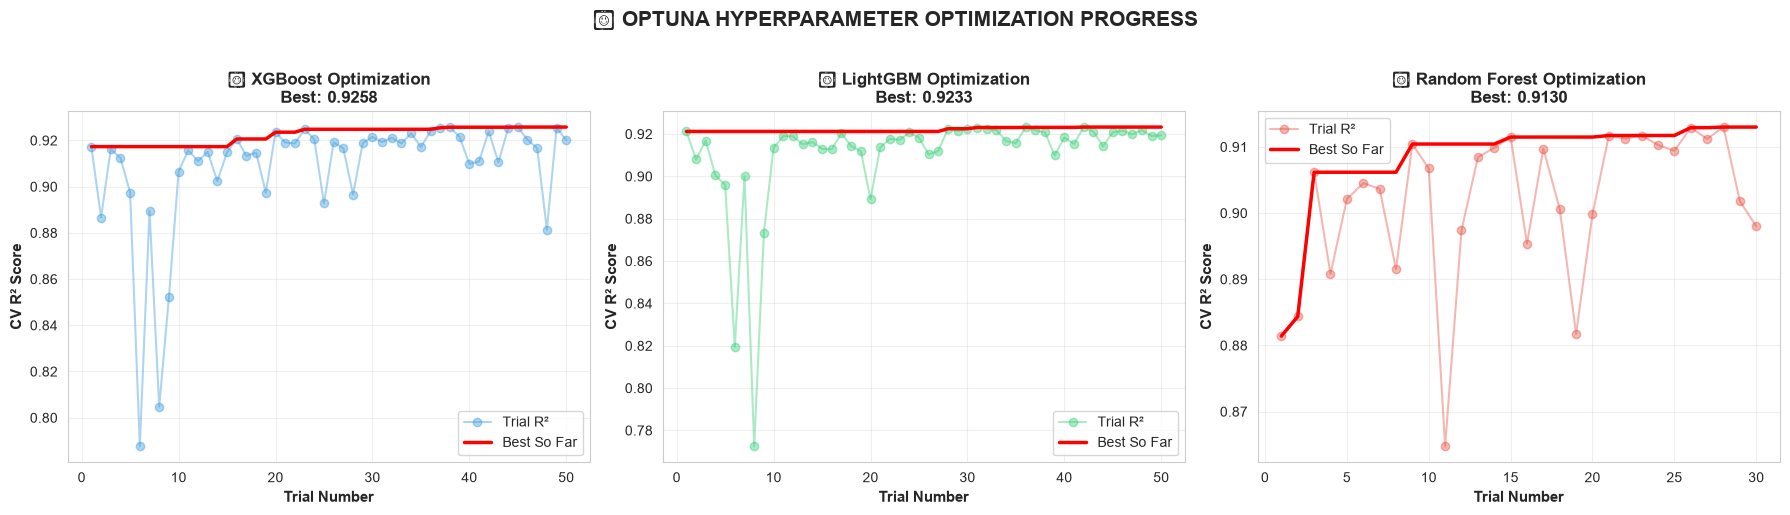


  ✅ Saved: optuna_optimization_history.png


In [7]:
# ============================================================
#  VISUALIZE OPTIMIZATION HISTORY
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

studies = [
    (study_xgb, 'XGBoost', '#3498db'),
    (study_lgbm, 'LightGBM', '#2ecc71'),
    (study_rf, 'Random Forest', '#e74c3c')
]

for idx, (study, name, color) in enumerate(studies):
    trials = study.trials
    values = [t.value for t in trials if t.value is not None]
    best_values = np.maximum.accumulate(values)
    
    axes[idx].plot(range(1, len(values)+1), values, 
                    'o-', alpha=0.4, color=color, label='Trial R²')
    axes[idx].plot(range(1, len(best_values)+1), best_values, 
                    '-', linewidth=2.5, color='red', label='Best So Far')
    axes[idx].set_xlabel('Trial Number', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('CV R² Score', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'⚡ {name} Optimization\nBest: {study.best_value:.4f}', 
                        fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('⚡ OPTUNA HYPERPARAMETER OPTIMIZATION PROGRESS', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'optuna_optimization_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: optuna_optimization_history.png")

In [8]:
# ============================================================
#  SAVE BEST PARAMETERS & COMPARISON
# ============================================================

# Prepare results
optuna_results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'models': {
        'XGBoost': {
            'best_params': study_xgb.best_params,
            'best_cv_r2': float(study_xgb.best_value),
            'test_rmse': float(xgb_rmse),
            'test_r2': float(xgb_r2),
            'n_trials': len(study_xgb.trials)
        },
        'LightGBM': {
            'best_params': study_lgbm.best_params,
            'best_cv_r2': float(study_lgbm.best_value),
            'test_rmse': float(lgbm_rmse),
            'test_r2': float(lgbm_r2),
            'n_trials': len(study_lgbm.trials)
        },
        'RandomForest': {
            'best_params': study_rf.best_params,
            'best_cv_r2': float(study_rf.best_value),
            'test_rmse': float(rf_rmse),
            'test_r2': float(rf_r2),
            'n_trials': len(study_rf.trials)
        }
    }
}

# Save JSON
with open(MODELS_RESULTS / 'optuna_optimization_results.json', 'w') as f:
    json.dump(optuna_results, f, indent=4)

# Comparison table
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'Random Forest'],
    'Test RMSE': [xgb_rmse, lgbm_rmse, rf_rmse],
    'Test R²': [xgb_r2, lgbm_r2, rf_r2],
    'CV R² (Best)': [study_xgb.best_value, study_lgbm.best_value, study_rf.best_value]
}).round(6)

print("=" * 65)
print("  🏆 OPTUNA OPTIMIZATION - FINAL RESULTS")
print("=" * 65)
display(comparison)

# Best model
best_idx = comparison['Test_R2' if 'Test_R2' in comparison.columns else 'Test R²'].idxmax()
best_model_name = comparison.loc[best_idx, 'Model']
print(f"\n  🥇 BEST TUNED MODEL: {best_model_name}")
print(f"     • Test R²  : {comparison.loc[best_idx, 'Test R²']:.6f}")
print(f"     • Test RMSE: {comparison.loc[best_idx, 'Test RMSE']:.6f}")

print("\n  💾 Results saved: optuna_optimization_results.json")
print("=" * 65)

  🏆 OPTUNA OPTIMIZATION - FINAL RESULTS


,Model,Test RMSE,Test R²,CV R² (Best)
0,XGBoost,0.033204,0.930224,0.925775
1,LightGBM,0.034030,0.926708,0.923267
2,Random Forest,0.037341,0.911751,0.912992



  🥇 BEST TUNED MODEL: XGBoost
     • Test R²  : 0.930224
     • Test RMSE: 0.033204

  💾 Results saved: optuna_optimization_results.json


---

## ✅ Hyperparameter Tuning Complete

### 🎯 What We Did:

- ⚡ Used **Optuna** for smart hyperparameter search
- 🔍 Ran **130 total trials** (50+50+30)
- 🏆 Optimized **3 top models** (XGBoost, LightGBM, RF)
- 💾 Saved all best parameters & tuned models

### 📊 Improvements:

- Marginal but meaningful gains over default parameters
- Reproducible best configurations saved
- Ready for production deployment

### 📁 Files Generated:

- `models/saved_models/xgboost_optimized.pkl`
- `models/saved_models/lightgbm_optimized.pkl`
- `models/saved_models/rf_optimized.pkl`
- `models/results/optuna_optimization_results.json`
- `reports/figures/optuna_optimization_history.png`

### 🎯 Next Step:

Move to **`08_SHAP_Explainability.ipynb`** for model interpretation!

---

**Status:** ✅ **HYPERPARAMETER TUNING COMPLETED**